<a href="https://colab.research.google.com/github/verma-lokesh/case-study-2-credit-card-fraud-detection-/blob/main/creditcardfraud.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Credit Card Fraud Detection
import kagglehub

# Download latest version
path = kagglehub.dataset_download("mlg-ulb/creditcardfraud")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'creditcardfraud' dataset.
Path to dataset files: /kaggle/input/creditcardfraud


In [ ]:
import pandas as pd
import os

# See what files were downloaded
print(os.listdir(path))

['creditcard.csv']


In [ ]:
df=pd.read_csv(os.path.join(path,"creditcard.csv"))

In [ ]:
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [ ]:
df.shape

(284807, 31)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [ ]:
# fraud count
df['Class'].value_counts()

,count
Class,
0,284315
1,492


In [ ]:
print(df["Class"].value_counts(normalize=True) * 100)

Class
0    99.827251
1     0.172749
Name: proportion, dtype: float64


              284,807 transactions
                       │
             ┌─────────┴─────────┐
             │                   │
          80% Train            20% Test
          ~227,845             ~56,962
             │                   │
          SMOTE here          DON'T SMOTE
             │
          XGBoost
          

In [ ]:
#only .17% transaction are fradulent
#17 fraud transaction in every 10,000 transaction
#model could predicted normal for everything yet achieve the accuracy of 99.8%


In [ ]:
x=df.drop('Class',axis=1)
y=df.Class

In [ ]:
print(x.shape)
print(y.shape)

(284807, 30)
(284807,)


In [ ]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42,stratify=y)

In [ ]:
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

(227845, 30)
(56962, 30)
(227845,)
(56962,)


In [ ]:
#let's see the imbalance

x_train → 227,845 transactions × 30 features
x_test  →  56,962 transactions × 30 features

y_train → 227,845 answers
y_test  →  56,962 answers

x + y
 │
 ├── Training data (80%)
 │      ├── x_train → transaction information
 │      └── y_train → actual fraud/normal labels
 │
 └── Testing data (20%)
        ├── x_test → transaction information
        └── y_test → actual fraud/normal labels

In [ ]:
print("Before SMOTE:")
print(y_train.value_counts())
#

Before SMOTE:
Class
0    227451
1       394
Name: count, dtype: int64


In [ ]:
#SMOTE = Synthetic Minority Over-sampling Technique
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

x_train_smote, y_train_smote = smote.fit_resample(
    x_train,
    y_train
)

In [ ]:
print("After SMOTE:")
print(y_train_smote.value_counts())

After SMOTE:
Class
0    227451
1    227451
Name: count, dtype: int64


In [ ]:
#XGBoost
from xgboost import XGBClassifier

model = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    random_state=42,
    eval_metric="logloss"
)

In [ ]:
model.fit(x_train_smote, y_train_smote)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=200, n_jobs=None,
              num_parallel_tree=None, ...)

In [ ]:
y_prob = model.predict_proba(x_test)[:, 1]

In [ ]:
print(y_prob[:10])

[1.41350938e-05 3.79152493e-06 4.61829450e-06 6.26757014e-07
 1.11024456e-04 3.19849823e-05 4.98946656e-06 4.89776130e-06
 3.12554257e-05 5.31814067e-06]


In [ ]:
from sklearn.metrics import classification_report

y_pred = (y_prob >= 0.5).astype(int)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.75      0.89      0.81        98

    accuracy                           1.00     56962
   macro avg       0.87      0.94      0.91     56962
weighted avg       1.00      1.00      1.00     56962



In [ ]:
print(y_pred[:20])

[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]


In [ ]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print(cm)

[[56835    29]
 [   11    87]]


In [ ]:
from sklearn.metrics import roc_auc_score

roc_auc = roc_auc_score(y_test, y_prob)

print("ROC-AUC:", roc_auc)

ROC-AUC: 0.9824052088477485


In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score

thresholds = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]

for threshold in thresholds:

    y_pred_threshold = (y_prob >= threshold).astype(int)

    precision = precision_score(y_test, y_pred_threshold)
    recall = recall_score(y_test, y_pred_threshold)
    f1 = f1_score(y_test, y_pred_threshold)

    print(
        f"Threshold: {threshold:.1f} | "
        f"Precision: {precision:.3f} | "
        f"Recall: {recall:.3f} | "
        f"F1: {f1:.3f}"
    )

Threshold: 0.1 | Precision: 0.463 | Recall: 0.888 | F1: 0.608
Threshold: 0.2 | Precision: 0.580 | Recall: 0.888 | F1: 0.702
Threshold: 0.3 | Precision: 0.696 | Recall: 0.888 | F1: 0.780
Threshold: 0.4 | Precision: 0.731 | Recall: 0.888 | F1: 0.802
Threshold: 0.5 | Precision: 0.750 | Recall: 0.888 | F1: 0.813
Threshold: 0.6 | Precision: 0.792 | Recall: 0.857 | F1: 0.824
Threshold: 0.7 | Precision: 0.822 | Recall: 0.847 | F1: 0.834
Threshold: 0.8 | Precision: 0.856 | Recall: 0.847 | F1: 0.851
Threshold: 0.9 | Precision: 0.892 | Recall: 0.847 | F1: 0.869


In [ ]:
from sklearn.metrics import average_precision_score

pr_auc = average_precision_score(y_test, y_prob)

print("PR-AUC:", pr_auc)

PR-AUC: 0.8793022398496981


best threshold automatically

In [ ]:
import numpy as np
from sklearn.metrics import precision_score, recall_score, f1_score

thresholds = np.arange(0.01, 1.00, 0.01)

results = []

for threshold in thresholds:
    y_pred_threshold = (y_prob >= threshold).astype(int)

    precision = precision_score(
        y_test,
        y_pred_threshold,
        zero_division=0
    )

    recall = recall_score(
        y_test,
        y_pred_threshold,
        zero_division=0
    )

    f1 = f1_score(
        y_test,
        y_pred_threshold,
        zero_division=0
    )

    results.append([threshold, precision, recall, f1])

results_df = pd.DataFrame(
    results,
    columns=["Threshold", "Precision", "Recall", "F1"]
)

best_row = results_df.loc[results_df["F1"].idxmax()]

print(best_row)

Threshold    0.970000
Precision    0.942529
Recall       0.836735
F1           0.886486
Name: 96, dtype: float64


interpret the model using feature importance scores.

In [ ]:
import matplotlib.pyplot as plt

importance = pd.Series(
    model.feature_importances_,
    index=x.columns
).sort_values(ascending=False)

print(importance.head(10))

V14    0.659975
V4     0.061445
V12    0.031428
V17    0.024219
V8     0.018463
V1     0.015893
V3     0.014275
V13    0.013643
V10    0.013289
V9     0.010730
dtype: float32


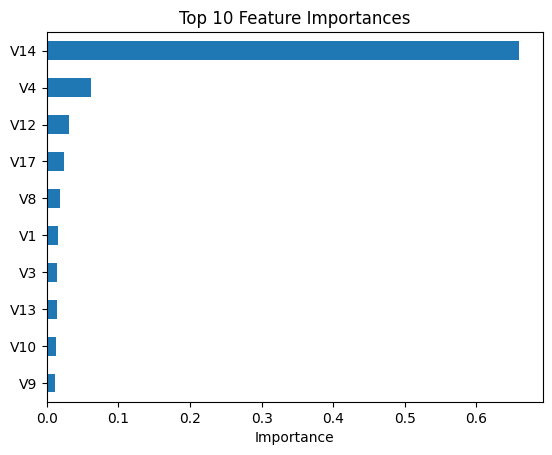

In [ ]:
importance.head(10).sort_values().plot(kind="barh")

plt.title("Top 10 Feature Importances")
plt.xlabel("Importance")
plt.show()

Dataset: 284,807 transactions
Fraud: 492
Normal: 284,315
ROC-AUC: 0.9824
PR-AUC: 0.8793
Best tested F1 threshold: 0.97
Precision at 0.97: 94.25%
Recall at 0.97: 83.67%
F1 at 0.97: 88.65%
Most important feature: V14 (65.9975%)